# Análise Exploratória (EDA)
Neste notebook utilizamos Matplotlib para analisar o risco regional e temporal do portfólio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuração Matplotlib
plt.style.use('ggplot')

contratos = pd.read_csv('contratos_clean.csv')
pagamentos = pd.read_csv('pagamentos_clean.csv', parse_dates=['Data_Vencimento', 'Data_Pagamento'])


### Inadimplência Regional

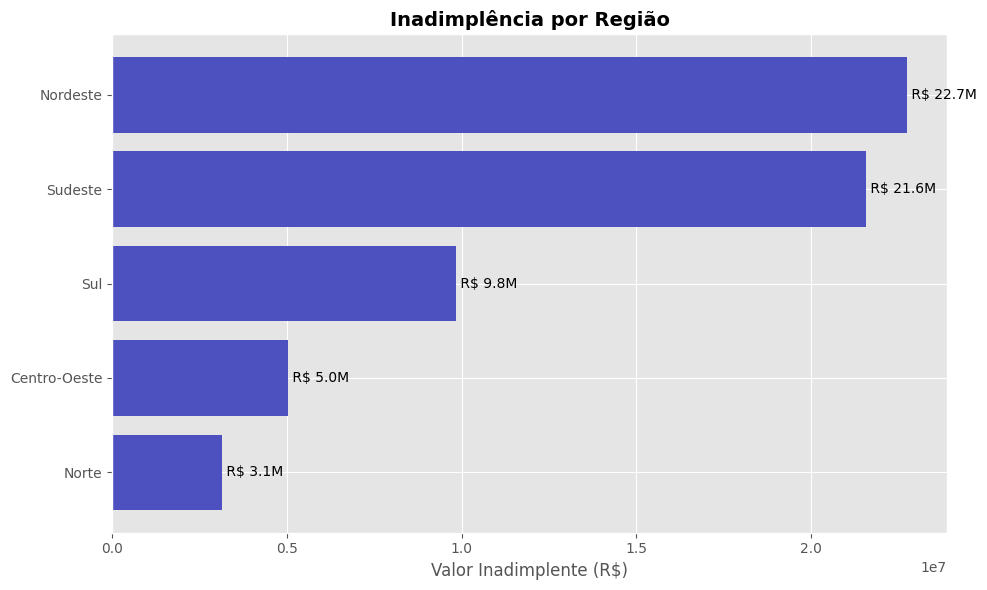

In [2]:
inad_regional = contratos.groupby('Regiao_Cliente')['Valor_Inadimplente_Inicial'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(inad_regional.index, inad_regional.values, color='#4c51bf')
plt.title('Inadimplência por Região', fontsize=14, fontweight='bold')
plt.xlabel('Valor Inadimplente (R$)')
for i, v in enumerate(inad_regional.values):
    plt.text(v, i, f' R$ {v/1e6:.1f}M', va='center')
plt.tight_layout()
plt.show()

### Recuperação Temporal de Pagamentos

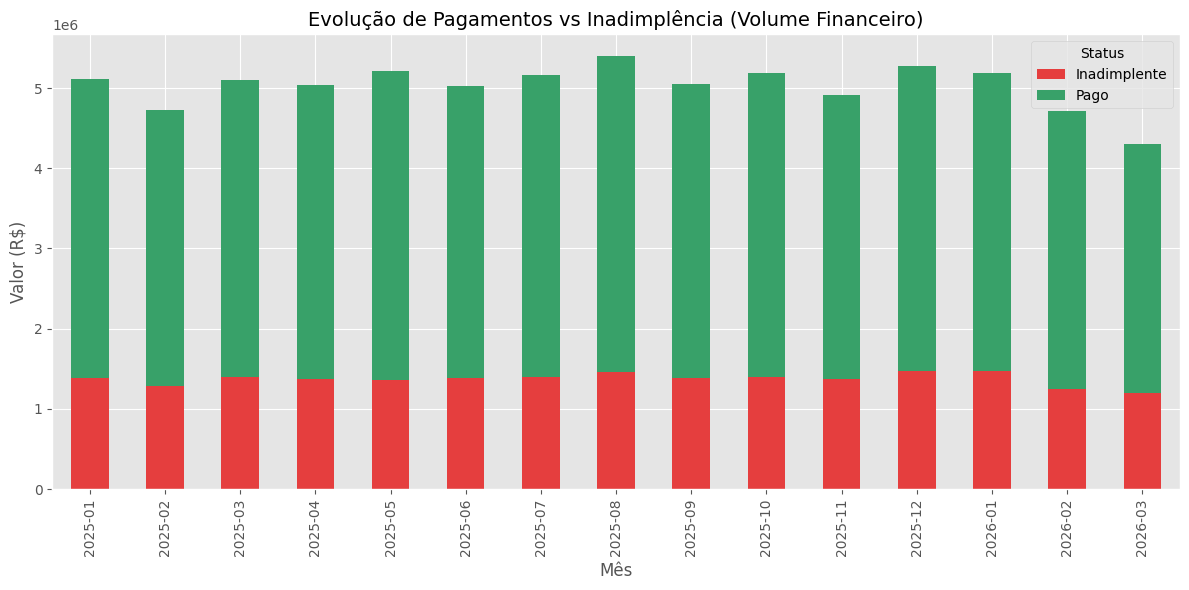

In [3]:
pagamentos['Mes_Vencimento'] = pagamentos['Data_Vencimento'].dt.to_period('M')
pagamentos['Status'] = pagamentos['Data_Pagamento'].notna().map({True: 'Pago', False: 'Inadimplente'})

evolucao = pagamentos.groupby(['Mes_Vencimento', 'Status'])['Valor_Parcela'].sum().unstack().fillna(0)

evolucao.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#e53e3e', '#38a169'])
plt.title('Evolução de Pagamentos vs Inadimplência (Volume Financeiro)', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Valor (R$)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()